# 03 – Preprocessing: Reescalamiento, Estandarización y Normalización

**Proyecto:** Predicción de Subempleo por Insuficiencia de Horas — EPEN 2024  
**Dataset de entrada:** `epen_outliers_handled.csv` (universo analítico: trabajadores ocupados >= 14 años)

---

## Objetivo

Este notebook transforma **únicamente** variables cuantitativas reales para que estén en escalas comparables antes de ser usadas en modelos sensibles a escala.

El escalamiento es importante para los siguientes tipos de modelos:

- **Regresión logística**: penaliza coeficientes en función de la escala de las variables.
- **SVM**: la distancia entre puntos depende directamente de la escala.
- **KNN**: las distancias euclidianas se ven dominadas por variables con rangos grandes.
- **Redes neuronales**: el gradiente converge mejor cuando las entradas tienen escala similar.
- **PCA**: la varianza total depende de la escala; variables con valores grandes dominan los componentes.

Los modelos basados en árboles como **Decision Tree** y **Random Forest** no requieren estrictamente escalamiento, ya que sus particiones son monótonas y no dependen de la magnitud absoluta.

En este proyecto se generará una versión escalada principalmente para modelos lineales como **Regresión Logística**, mientras que los modelos de árboles podrán usar las variables originales sin escalar.

## 1. Cargar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Cargar dataset

In [2]:
BASE_DIR = Path("..") / "data" / "processed"

PREFERRED = BASE_DIR / "epen_outliers_handled.csv"
FALLBACK   = BASE_DIR / "epen_missing_handled.csv"

if PREFERRED.exists():
    df = pd.read_csv(PREFERRED, low_memory=False)
    print(f"Dataset cargado: {PREFERRED.name}")
elif FALLBACK.exists():
    df = pd.read_csv(FALLBACK, low_memory=False)
    print(f"Archivo preferido no encontrado. Dataset cargado: {FALLBACK.name}")
    print("AVISO: Se recomienda ejecutar 02_outliers_handling.ipynb antes de continuar.")
else:
    raise FileNotFoundError(
        "No se encontró ningún dataset de entrada.\n"
        "Ejecuta primero:\n"
        "  1. 01_missing_values_handling.ipynb\n"
        "  2. 02_outliers_handling.ipynb"
    )

print(f"\nDimensiones : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Tipos de dato:\n{df.dtypes.value_counts().to_string()}")
print(f"\nPrimeras filas:")
display(df.head(3))

print("\nDistribucion de target_subempleo_horas:")
if "target_subempleo_horas" in df.columns:
    dist = df["target_subempleo_horas"].value_counts().rename_axis("clase").reset_index(name="n")
    dist["pct"] = (dist["n"] / len(df) * 100).round(2)
    display(dist)
else:
    print("  ADVERTENCIA: 'target_subempleo_horas' no encontrado en el dataset.")

Dataset cargado: epen_outliers_handled.csv

Dimensiones : 24,054 filas x 149 columnas
Tipos de dato:
int64      62
object     58
float64    29

Primeras filas:


,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,C203,C204,C205,C206,C207,C208,C300n,NROINF,C301_DIA,C301_MES,C301_ANIO,C303,C304,C305,C306_1,C306_2,C306_3,C306_4,C306_5,C306_6,...,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,fa_ond24,fa_efm24,fa_amj24,fa_jas24,C208_num,OCUP300_num,P209H_num,target_subempleo_horas,whoraT_missing_flag,C318_T_missing_flag,C208_outlier_flag,whoraT_outlier_flag,INGTOT_outlier_flag,INGTRABW_outlier_flag,INGTOT_log,INGTOTP_log,INGTRABW_log,I339_1_log,I342_log,I345_1_log,I348_log
0,2024,10,18117,2,61,1,1,202410181172006016.0000,1,1,1,1,2,,2,60.0000,1,1,19.0000,5.0000,1964,1,,,,,,,,,...,NaN,NaN,,,,1367.0000,1367.0000,1367.0000,1,700.4007,NaN,NaN,NaN,60.0000,1.0000,2.0000,0,0,0,0,0,0,0,7.2211,7.2211,7.2211,NaN,7.2211,NaN,NaN
1,2024,10,18117,2,61,1,1,202410181172006016.0000,1,2,7,1,2,,2,49.0000,2,2,30.0000,11.0000,1974,1,,,,,,,,,...,NaN,NaN,,,,1534.0000,1534.0000,1534.0000,1,700.4007,NaN,NaN,NaN,49.0000,1.0000,1.0000,1,0,0,0,0,0,0,7.3363,7.3363,7.3363,NaN,7.2478,NaN,NaN
2,2024,10,1823302,1,59,1,1,20241018233021001728.0000,1,1,1,1,2,,1,52.0000,1,2,14.0000,9.0000,1972,1,,,,,,,,,...,NaN,NaN,,,,1400.0000,1400.0000,1400.0000,1,896.4695,NaN,NaN,NaN,52.0000,1.0000,2.0000,0,0,0,0,0,0,0,7.2449,7.2449,7.2449,NaN,7.2449,NaN,NaN



Distribucion de target_subempleo_horas:


,clase,n,pct
0,0,18064,75.1000
1,1,5990,24.9000


## 3. Validación inicial

In [3]:
TARGET_COL  = "target_subempleo_horas"
LEAKAGE_VARS = ["P209H", "C333", "C334"]

# 1. Confirmar existencia del target
assert TARGET_COL in df.columns, f"ERROR: '{TARGET_COL}' no encontrado en el dataset."
print(f"  '{TARGET_COL}' encontrado.")

# 2. Confirmar que el target no tiene nulos
assert df[TARGET_COL].isnull().sum() == 0, f"ERROR: '{TARGET_COL}' tiene nulos."
print(f"  '{TARGET_COL}' sin valores nulos.")

# 3. Confirmar que el target no será escalado (se mantendrá excluido de scaling_columns)
print(f"  '{TARGET_COL}' NO sera escalado.")

# 4. Variables de leakage presentes en el dataset
leakage_found = [v for v in LEAKAGE_VARS if v in df.columns]
if leakage_found:
    print(f"\nVariables de leakage encontradas: {leakage_found}")
    print("  Seran excluidas de cualquier transformacion.")
else:
    print("\nNo se encontraron variables de leakage en el dataset.")

print("\nValidacion inicial completada.")

  'target_subempleo_horas' encontrado.
  'target_subempleo_horas' sin valores nulos.
  'target_subempleo_horas' NO sera escalado.

Variables de leakage encontradas: ['P209H', 'C333', 'C334']
  Seran excluidas de cualquier transformacion.

Validacion inicial completada.


## 4. Clasificación conceptual de variables

No toda variable numérica debe ser escalada. En la EPEN, muchas columnas almacenan valores enteros que, en realidad, son **códigos de respuesta**, **identificadores** o **indicadores binarios**, no magnitudes continuas.

**Variables que SÍ pueden escalarse:**

| Tipo | Ejemplos |
|------|----------|
| Edad (años) | C208 |
| Horas trabajadas (horas) | C318_T, C328_T, whoraT, C331 |
| Ingresos (soles) | INGTOT, INGTOTP, INGTRABW, I339_1, I342, I345_1, I348 |
| Ingresos transformados (log1p) | INGTOT_log, INGTOTP_log, INGTRABW_log |

**Variables que NO deben escalarse:**

| Tipo | Descripcion |
|------|-------------|
| Target | `target_subempleo_horas` — variable objetivo binaria |
| Variables de leakage | `P209H`, `C333`, `C334` — causarían fuga de información |
| Identificadores administrativos | `ANIO`, `MES`, `CONGLOMERADO`, `MUESTRA`, `HOGAR`, etc. |
| Variables binarias / dummies | Columnas con solo {0,1} o {1,2} |
| Códigos categóricos | Sexo, nivel educativo codificado, categoría de ocupación, etc. |
| Variables ordinales discretas | Salvo decisión explícita de tratarlas como cuantitativas |

## 5. Definir variables cuantitativas reales candidatas

In [4]:
# Lista de candidatos a escalar: solo variables cuantitativas reales
true_numeric_candidates = [
    # Edad
    "C208",
    # Horas trabajadas
    "C318_T", "C328_T", "whoraT", "C331",
    # Ingresos originales
    "INGTOT", "INGTOTP", "INGTRABW", "ingtrabw",
    "I339_1", "I342", "I345_1", "I348",
    # Ingresos transformados con log1p (si existen)
    "INGTOT_log", "INGTOTP_log", "INGTRABW_log", "ingtrabw_log",
]

# Razón asociada a cada candidato (para la tabla de validación)
candidate_reasons = {
    "C208"       : "Edad medida en años",
    "C318_T"     : "Horas trabajadas medidas en horas",
    "C328_T"     : "Horas trabajadas medidas en horas",
    "whoraT"     : "Horas trabajadas medidas en horas",
    "C331"       : "Horas trabajadas medidas en horas",
    "INGTOT"     : "Ingreso medido en soles",
    "INGTOTP"    : "Ingreso medido en soles",
    "INGTRABW"   : "Ingreso medido en soles",
    "ingtrabw"   : "Ingreso medido en soles",
    "I339_1"     : "Ingreso medido en soles",
    "I342"       : "Ingreso medido en soles",
    "I345_1"     : "Ingreso medido en soles",
    "I348"       : "Ingreso medido en soles",
    "INGTOT_log" : "Ingreso transformado con log1p",
    "INGTOTP_log": "Ingreso transformado con log1p",
    "INGTRABW_log": "Ingreso transformado con log1p",
    "ingtrabw_log": "Ingreso transformado con log1p",
}

# Filtrar: solo los que existen en el DataFrame y son de tipo numérico
scaling_columns = []
for col in true_numeric_candidates:
    if col in df.columns:
        # Coercer a numérico si está como object
        if df[col].dtype == object:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        if pd.api.types.is_numeric_dtype(df[col]):
            scaling_columns.append(col)

print(f"Candidatos originales    : {len(true_numeric_candidates)}")
print(f"Columnas en el dataset   : {sum(c in df.columns for c in true_numeric_candidates)}")
print(f"Columnas numericas validas: {len(scaling_columns)}")
print(f"\nscaling_columns = {scaling_columns}")

Candidatos originales    : 17
Columnas en el dataset   : 15
Columnas numericas validas: 15

scaling_columns = ['C208', 'C318_T', 'C328_T', 'whoraT', 'C331', 'INGTOT', 'INGTOTP', 'ingtrabw', 'I339_1', 'I342', 'I345_1', 'I348', 'INGTOT_log', 'INGTOTP_log', 'INGTRABW_log']


## 6. Definir variables que NO se escalan

Las variables listadas a continuación no serán incluidas en ningún proceso de escalamiento,
ya que representan categorías, respuestas binarias, códigos de encuesta u órdenes discretos:
no son magnitudes continuas.

In [5]:
target_variable = [TARGET_COL]

leakage_variables = ["P209H", "C333", "C334"]

id_variables = [
    "ANIO", "MES", "CONGLOMERADO", "MUESTRA", "SELVIV",
    "HOGAR", "LLAVE_PANEL", "C201", "C300n", "NROINF", "fa_son24"
]

categorical_code_variables = [
    "C203", "C207", "C310", "C311", "C312", "C313",
    "C317", "C335", "SEGURO1", "C361_1", "C361_5",
    "C364_1", "C364_2", "C366", "C376", "C377",
    "C375_1", "C375_2", "C375_3", "C375_4", "C375_5", "C375_6"
]

excluded_explicit = set(
    target_variable + leakage_variables + id_variables + categorical_code_variables
)

# Verificar cuáles de estas realmente existen en el DataFrame
excluded_found = [v for v in excluded_explicit if v in df.columns]

print(f"Variables explicitamente excluidas del escalamiento: {len(excluded_found)}")
for v in sorted(excluded_found):
    print(f"  {v}")

Variables explicitamente excluidas del escalamiento: 36
  ANIO
  C201
  C203
  C207
  C300n
  C310
  C311
  C312
  C313
  C317
  C333
  C334
  C335
  C361_1
  C361_5
  C364_1
  C364_2
  C366
  C375_1
  C375_2
  C375_3
  C375_4
  C375_5
  C375_6
  C376
  C377
  CONGLOMERADO
  HOGAR
  LLAVE_PANEL
  MES
  MUESTRA
  NROINF
  P209H
  SEGURO1
  SELVIV
  target_subempleo_horas


## 7. Detectar y excluir variables binarias automáticamente

In [6]:
def is_binary_column(series):
    """Retorna True si la columna solo contiene valores en {0,1} o {1,2}, ignorando nulos."""
    vals = set(series.dropna().unique())
    return vals <= {0, 1} or vals <= {1, 2}

# Detectar todas las columnas binarias en el DataFrame (numéricas)
num_cols_all = df.select_dtypes(include="number").columns.tolist()
binary_columns_detected = [c for c in num_cols_all if is_binary_column(df[c])]

print(f"Columnas binarias detectadas automaticamente: {len(binary_columns_detected)}")
for bc in sorted(binary_columns_detected):
    print(f"  {bc}")

# Remover de scaling_columns cualquier binaria que no tenga sentido cuantitativo
# (las candidatas en true_numeric_candidates ya son cuantitativas reales)
before = len(scaling_columns)
scaling_columns = [c for c in scaling_columns if c not in binary_columns_detected]
after = len(scaling_columns)

print(f"\nscaling_columns antes de filtro binario: {before}")
print(f"scaling_columns despues de filtro binario: {after}")
if before != after:
    removed = [c for c in true_numeric_candidates if c in binary_columns_detected]
    print(f"Columnas removidas: {removed}")

Columnas binarias detectadas automaticamente: 38
  C204
  C207
  C208_outlier_flag
  C303
  C318_T_missing_flag
  C330
  C333
  C359
  C361_1
  C361_2
  C361_3
  C361_4
  C361_5
  C361_6
  C361_7
  C361_8
  C364_1
  C364_2
  C364_3
  C364_4
  C375_1
  C375_2
  C375_3
  C375_4
  C375_5
  C375_6
  INGTOT_outlier_flag
  INGTRABW_outlier_flag
  MUESTRA
  OCUP300
  OCUP300_num
  P209H
  P209H_num
  REGION
  RESIDENT
  target_subempleo_horas
  whoraT_missing_flag
  whoraT_outlier_flag

scaling_columns antes de filtro binario: 15
scaling_columns despues de filtro binario: 15


## 8. Validar columnas finales a escalar

In [7]:
rows = []
for col in scaling_columns:
    s = pd.to_numeric(df[col], errors="coerce")
    rows.append({
        "variable"      : col,
        "dtype"         : str(df[col].dtype),
        "nulos"         : int(s.isnull().sum()),
        "minimo"        : round(s.min(), 4),
        "maximo"        : round(s.max(), 4),
        "razon"         : candidate_reasons.get(col, "Variable cuantitativa"),
    })

scaling_info = pd.DataFrame(rows)
print(f"Columnas que se escalaran: {len(scaling_columns)}")
display(scaling_info)

Columnas que se escalaran: 15


,variable,dtype,nulos,minimo,maximo,razon
0,C208,float64,0,14.0000,92.0000,Edad medida en años
1,C318_T,float64,0,0.0000,112.0000,Horas trabajadas medidas en horas
2,C328_T,float64,21604,2.0000,87.0000,Horas trabajadas medidas en horas
3,whoraT,float64,0,2.0000,112.0000,Horas trabajadas medidas en horas
4,C331,float64,20614,2.0000,112.0000,Horas trabajadas medidas en horas
5,INGTOT,float64,774,3.0000,40000.0000,Ingreso medido en soles
6,INGTOTP,float64,774,3.0000,40000.0000,Ingreso medido en soles
7,ingtrabw,float64,774,3.0000,40000.0000,Ingreso medido en soles
8,I339_1,float64,9203,42.0000,32000.0000,Ingreso medido en soles
9,I342,float64,15643,1.0000,40000.0000,Ingreso medido en soles


## 9. Resumen estadístico antes del escalamiento

In [8]:
percentiles = [0.25, 0.50, 0.75]
pct_labels  = ["p25", "p50", "p75"]

summary_rows = []
for col in scaling_columns:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    pcts = s.quantile(percentiles).to_numpy()
    row = {
        "variable": col,
        "count"   : int(s.count()),
        "mean"    : round(s.mean(), 4),
        "std"     : round(s.std(), 4),
        "min"     : round(s.min(), 4),
    }
    for lbl, val in zip(pct_labels, pcts):
        row[lbl] = round(val, 4)
    row["max"] = round(s.max(), 4)
    summary_rows.append(row)

scaling_summary_before = pd.DataFrame(summary_rows).set_index("variable")
print("Resumen estadistico antes del escalamiento:")
display(scaling_summary_before)

Resumen estadistico antes del escalamiento:


,count,mean,std,min,p25,p50,p75,max
variable,,,,,,,,
C208,24054,42.0250,14.7876,14.0000,30.0000,41.0000,53.0000,92.0000
C318_T,24054,40.7753,18.8387,0.0000,30.0000,42.0000,50.0000,112.0000
C328_T,2450,14.3576,12.1527,2.0000,6.0000,10.0000,20.0000,87.0000
whoraT,24054,44.4966,17.9011,2.0000,36.0000,46.0000,54.0000,112.0000
C331,3440,42.4012,16.2587,2.0000,32.0000,45.0000,48.0000,112.0000
INGTOT,23280,2047.3829,2064.6638,3.0000,1025.0000,1516.0000,2500.0000,40000.0000
INGTOTP,23280,1976.7484,1956.6198,3.0000,1025.0000,1500.0000,2400.0000,40000.0000
ingtrabw,23280,2195.8287,2324.5455,3.0000,1033.0000,1603.0000,2570.0000,40000.0000
I339_1,14851,2084.2050,1908.2990,42.0000,1050.0000,1500.0000,2500.0000,32000.0000


## 10. Visualización antes del escalamiento

Los ingresos en la EPEN suelen tener alta asimetría positiva (colas largas hacia valores altos).
Las variables logarítmicas (`INGTOT_log`, etc.) aproximan mejor la distribución normal, lo que las hace
más adecuadas para modelos lineales como la Regresión Logística.

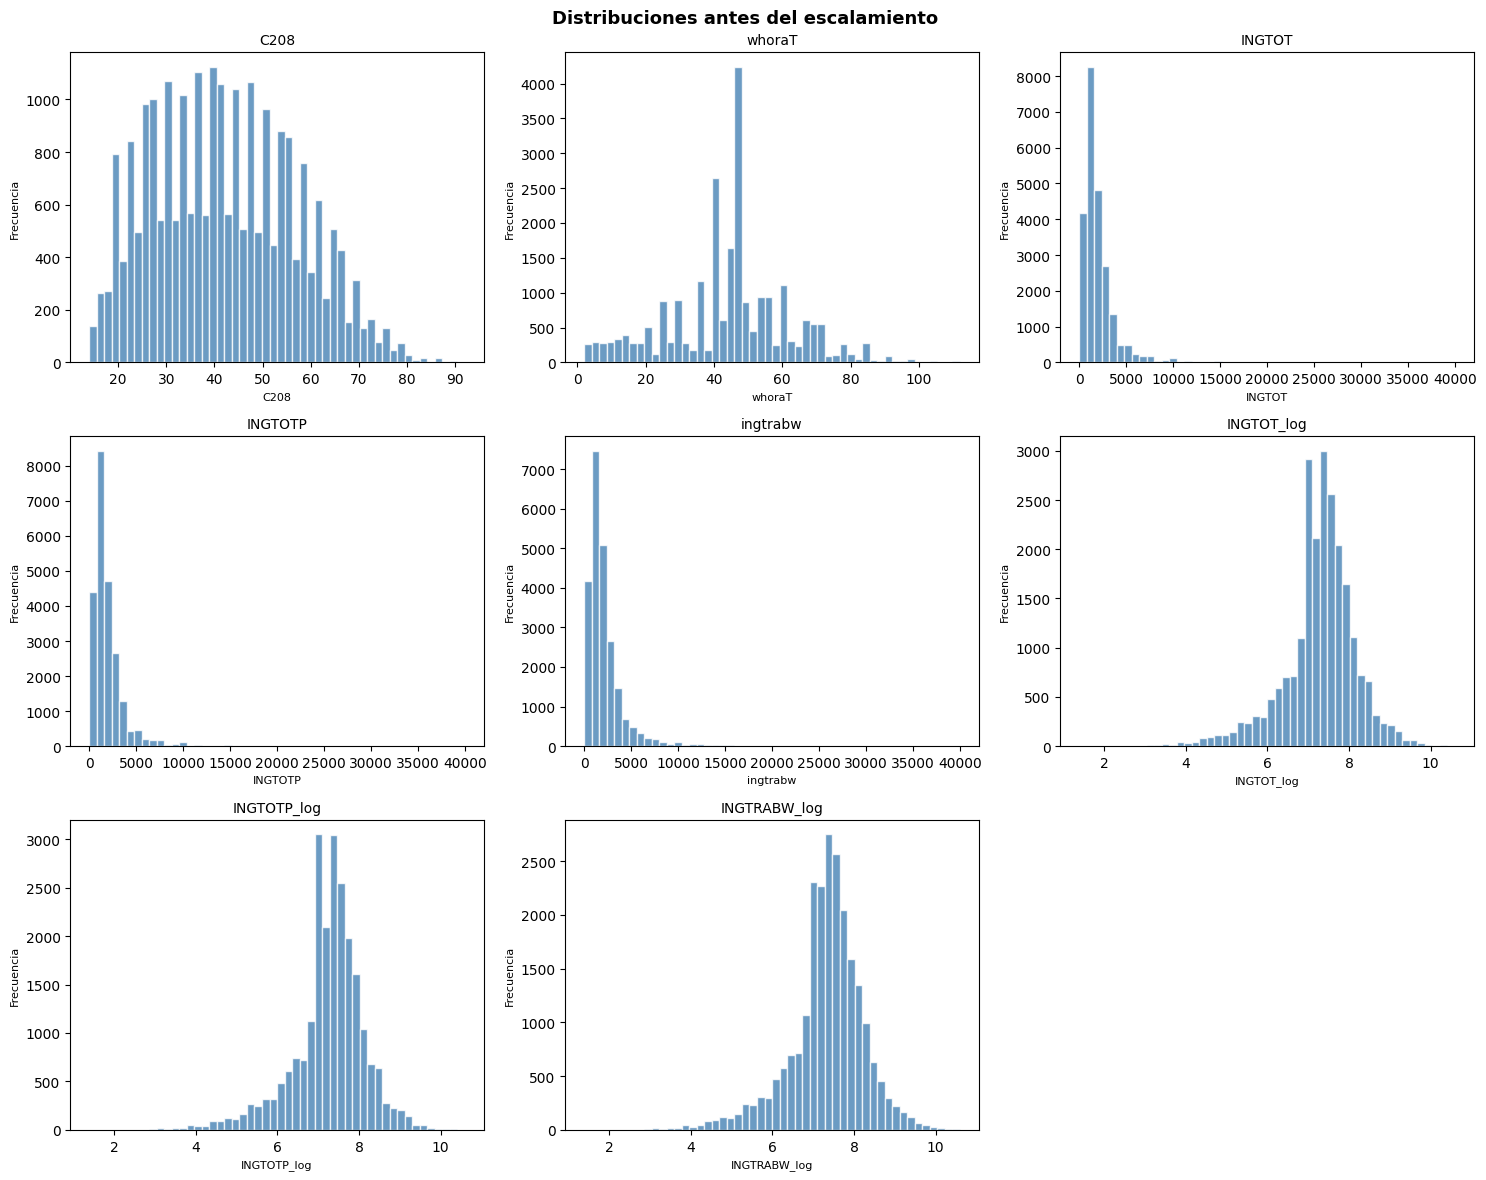

In [9]:
viz_candidates = ["C208", "whoraT", "INGTOT", "INGTOTP",
                  "INGTRABW", "ingtrabw",
                  "INGTOT_log", "INGTOTP_log", "INGTRABW_log", "ingtrabw_log"]

viz_cols = [c for c in viz_candidates if c in df.columns and c in scaling_columns]

if not viz_cols:
    print("No hay columnas de visualizacion disponibles.")
else:
    n_cols = 3
    n_rows = (len(viz_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, col in enumerate(viz_cols):
        data = pd.to_numeric(df[col], errors="coerce").dropna()
        ax = axes_flat[i]
        ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel("Frecuencia", fontsize=8)

    # Ocultar ejes sobrantes
    for j in range(len(viz_cols), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle("Distribuciones antes del escalamiento", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 11. Métodos de escalamiento

### StandardScaler

Transforma cada variable para que tenga **media 0 y desviación estándar 1**:

$$z = \frac{x - \mu}{\sigma}$$

Es el escalamiento estándar para regresión logística y modelos lineales en general.
Asume que los datos tienen una distribución aproximadamente normal.

### MinMaxScaler

Transforma cada variable a un **rango entre 0 y 1**:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Util cuando se desea una escala acotada. Sensible a valores extremos.

### RobustScaler

Usa la **mediana y el rango intercuartílico** (IQR):

$$x' = \frac{x - Q_{50}}{Q_{75} - Q_{25}}$$

Es más resistente a outliers que StandardScaler o MinMaxScaler.
Dado que la EPEN puede tener ingresos y horas con valores extremos, **RobustScaler es la opcion principal** para este proyecto.

## 12. Crear copias de trabajo y aplicar escalamiento

In [10]:
df_standard_scaled = df.copy()
df_minmax_scaled   = df.copy()
df_robust_scaled   = df.copy()

# Preparar matriz de valores (coerción a numérico y manejo de nulos)
X = df[scaling_columns].apply(pd.to_numeric, errors="coerce")

print(f"Copias de trabajo creadas.")
print(f"Columnas a escalar: {len(scaling_columns)}")

Copias de trabajo creadas.
Columnas a escalar: 15


### 12.1 Aplicar StandardScaler

In [11]:
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

std_cols = [f"{c}_std" for c in scaling_columns]
df_standard = pd.DataFrame(X_std, columns=std_cols, index=df.index)

for col in std_cols:
    df_standard_scaled[col] = df_standard[col]

print("StandardScaler aplicado. Columnas creadas:")
for c in std_cols:
    print(f"  {c}")

StandardScaler aplicado. Columnas creadas:
  C208_std
  C318_T_std
  C328_T_std
  whoraT_std
  C331_std
  INGTOT_std
  INGTOTP_std
  ingtrabw_std
  I339_1_std
  I342_std
  I345_1_std
  I348_std
  INGTOT_log_std
  INGTOTP_log_std
  INGTRABW_log_std


### 12.2 Aplicar MinMaxScaler

In [12]:
mm_scaler = MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)

mm_cols = [f"{c}_minmax" for c in scaling_columns]
df_minmax = pd.DataFrame(X_mm, columns=mm_cols, index=df.index)

for col in mm_cols:
    df_minmax_scaled[col] = df_minmax[col]

print("MinMaxScaler aplicado. Columnas creadas:")
for c in mm_cols:
    print(f"  {c}")

MinMaxScaler aplicado. Columnas creadas:
  C208_minmax
  C318_T_minmax
  C328_T_minmax
  whoraT_minmax
  C331_minmax
  INGTOT_minmax
  INGTOTP_minmax
  ingtrabw_minmax
  I339_1_minmax
  I342_minmax
  I345_1_minmax
  I348_minmax
  INGTOT_log_minmax
  INGTOTP_log_minmax
  INGTRABW_log_minmax


### 12.3 Aplicar RobustScaler

In [13]:
rob_scaler = RobustScaler()
X_rob = rob_scaler.fit_transform(X)

rob_cols = [f"{c}_robust" for c in scaling_columns]
df_robust = pd.DataFrame(X_rob, columns=rob_cols, index=df.index)

for col in rob_cols:
    df_robust_scaled[col] = df_robust[col]

print("RobustScaler aplicado. Columnas creadas:")
for c in rob_cols:
    print(f"  {c}")

RobustScaler aplicado. Columnas creadas:
  C208_robust
  C318_T_robust
  C328_T_robust
  whoraT_robust
  C331_robust
  INGTOT_robust
  INGTOTP_robust
  ingtrabw_robust
  I339_1_robust
  I342_robust
  I345_1_robust
  I348_robust
  INGTOT_log_robust
  INGTOTP_log_robust
  INGTRABW_log_robust


## 13. Construir dataset final escalado

Se construye `df_scaled` como copia del dataset original, añadiendo únicamente las columnas
escaladas con **RobustScaler** como transformación principal.

Las variables originales se conservan para:
- Trazabilidad y auditoría del proceso.
- Uso directo por modelos basados en árboles (Decision Tree, Random Forest) que no requieren escalamiento.

In [14]:
df_scaled = df.copy()

# Agregar solo columnas RobustScaler al dataset final
for col in rob_cols:
    df_scaled[col] = df_robust[col]

print(f"df_scaled construido: {df_scaled.shape[0]:,} filas x {df_scaled.shape[1]} columnas")
print(f"Columnas originales     : {df.shape[1]}")
print(f"Columnas robust añadidas: {len(rob_cols)}")
print(f"Total columnas finales  : {df_scaled.shape[1]}")

df_scaled construido: 24,054 filas x 164 columnas
Columnas originales     : 149
Columnas robust añadidas: 15
Total columnas finales  : 164


## 14. Comparación antes / después del escalamiento

In [15]:
comp_rows = []
for orig, s_col, mm_col, r_col in zip(scaling_columns, std_cols, mm_cols, rob_cols):
    s_orig = pd.to_numeric(df[orig], errors="coerce")
    s_std  = df_standard_scaled[s_col]
    s_mm   = df_minmax_scaled[mm_col]
    s_rob  = df_robust_scaled[r_col]
    comp_rows.append({
        "variable_original": orig,
        "variable_std"     : s_col,
        "variable_minmax"  : mm_col,
        "variable_robust"  : r_col,
        "media_original"   : round(s_orig.mean(), 4),
        "media_std"        : round(s_std.mean(), 4),
        "minmax_min"       : round(s_mm.min(), 4),
        "minmax_max"       : round(s_mm.max(), 4),
        "mediana_robust"   : round(s_rob.median(), 4),
    })

comparison_df = pd.DataFrame(comp_rows)
print("Tabla comparativa de escalamiento:")
display(comparison_df)

Tabla comparativa de escalamiento:


,variable_original,variable_std,variable_minmax,variable_robust,media_original,media_std,minmax_min,minmax_max,mediana_robust
0,C208,C208_std,C208_minmax,C208_robust,42.0250,-0.0000,0.0000,1.0000,0.0000
1,C318_T,C318_T_std,C318_T_minmax,C318_T_robust,40.7753,0.0000,0.0000,1.0000,0.0000
2,C328_T,C328_T_std,C328_T_minmax,C328_T_robust,14.3576,0.0000,0.0000,1.0000,0.0000
3,whoraT,whoraT_std,whoraT_minmax,whoraT_robust,44.4966,-0.0000,0.0000,1.0000,0.0000
4,C331,C331_std,C331_minmax,C331_robust,42.4012,-0.0000,0.0000,1.0000,0.0000
5,INGTOT,INGTOT_std,INGTOT_minmax,INGTOT_robust,2047.3829,0.0000,0.0000,1.0000,0.0000
6,INGTOTP,INGTOTP_std,INGTOTP_minmax,INGTOTP_robust,1976.7484,0.0000,0.0000,1.0000,0.0000
7,ingtrabw,ingtrabw_std,ingtrabw_minmax,ingtrabw_robust,2195.8287,0.0000,0.0000,1.0000,0.0000
8,I339_1,I339_1_std,I339_1_minmax,I339_1_robust,2084.2050,-0.0000,0.0000,1.0000,0.0000
9,I342,I342_std,I342_minmax,I342_robust,1574.0476,0.0000,0.0000,1.0000,0.0000


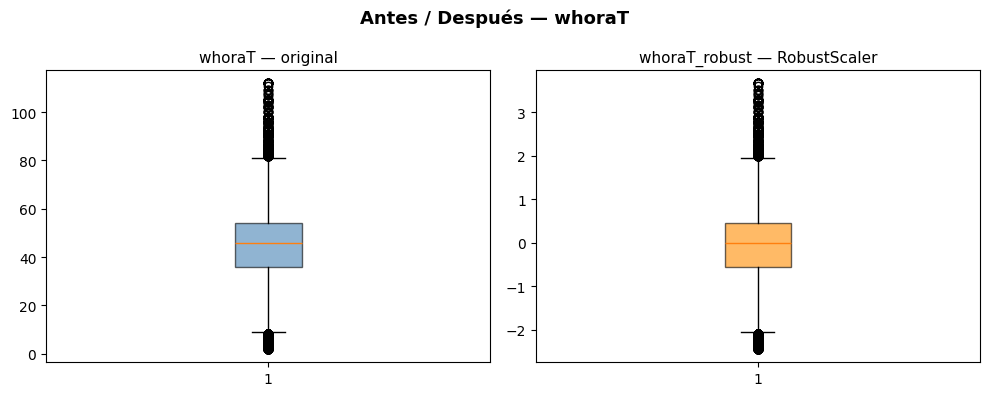

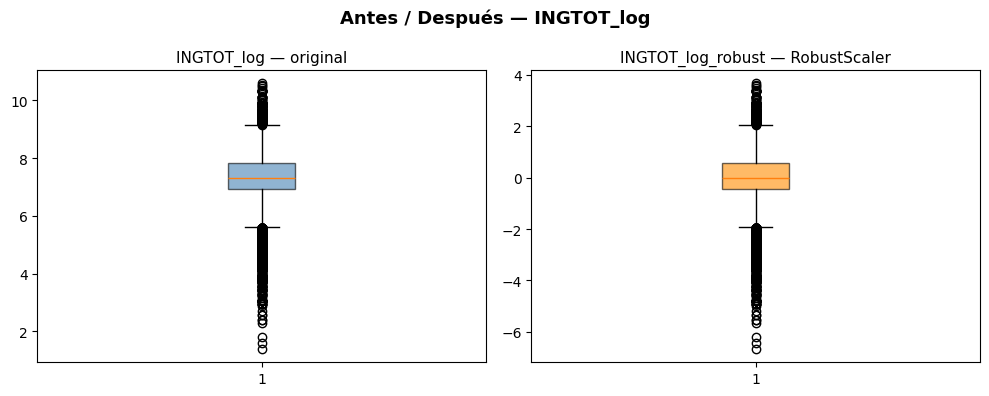

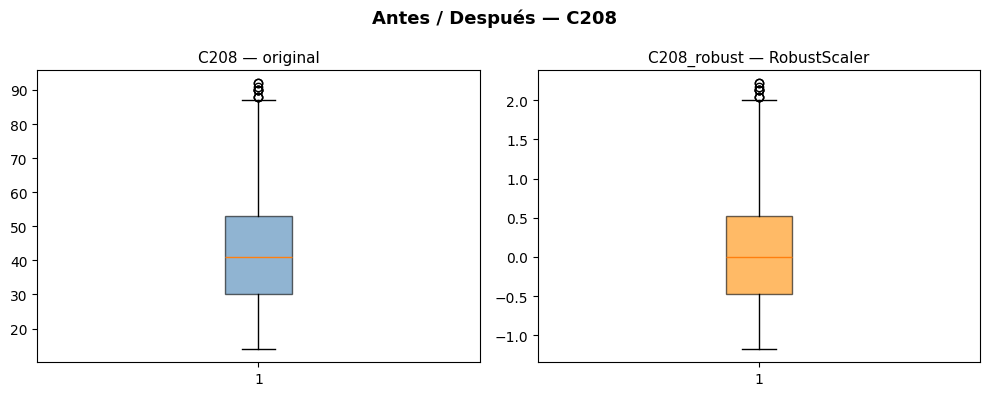

In [16]:
def plot_before_after_robust(orig_col, df_before, df_after_robust, suffix="_robust"):
    """Boxplot lado a lado: original vs RobustScaler."""
    rob_col = f"{orig_col}{suffix}"
    if orig_col not in df_before.columns or rob_col not in df_after_robust.columns:
        print(f"  Columna '{orig_col}' o '{rob_col}' no disponible.")
        return

    data_orig = pd.to_numeric(df_before[orig_col], errors="coerce").dropna()
    data_rob  = df_after_robust[rob_col].dropna()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.boxplot(data_orig, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax1.set_title(f"{orig_col} — original", fontsize=11)

    ax2.boxplot(data_rob, vert=True, patch_artist=True,
                boxprops=dict(facecolor="darkorange", alpha=0.6))
    ax2.set_title(f"{rob_col} — RobustScaler", fontsize=11)

    plt.suptitle(f"Antes / Después — {orig_col}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Graficos para variables relevantes
for col_to_plot in ["whoraT", "INGTOT_log", "C208"]:
    plot_before_after_robust(col_to_plot, df, df_robust_scaled)

## 15. Validación final

In [17]:
print("=" * 55)
print("VALIDACION FINAL")
print("=" * 55)

errors = []

# 1. Target presente y sin modificar
assert TARGET_COL in df_scaled.columns, "ERROR: target perdido."
assert df_scaled[TARGET_COL].isnull().sum() == 0, "ERROR: target tiene nulos."
assert TARGET_COL not in rob_cols, "ERROR: target fue escalado."
print(f"  '{TARGET_COL}' presente, sin nulos y no escalado.")

# 2. Variables de leakage no escaladas
for lv in LEAKAGE_VARS:
    if lv in df_scaled.columns:
        assert f"{lv}_robust" not in df_scaled.columns, f"ERROR: leakage '{lv}' fue escalada."
print(f"  Variables de leakage no escaladas.")

# 3. Variables administrativas no escaladas
for iv in id_variables:
    if f"{iv}_robust" in df_scaled.columns:
        errors.append(f"  ADVERTENCIA: identificador '{iv}' fue escalado.")
if not errors:
    print(f"  Identificadores administrativos no escalados.")
else:
    for e in errors: print(e)

# 4. Variables categoricas no escaladas
cat_scaled = [c for c in categorical_code_variables if f"{c}_robust" in df_scaled.columns]
if cat_scaled:
    print(f"  ADVERTENCIA: variables categoricas escaladas: {cat_scaled}")
else:
    print(f"  Variables categoricas no escaladas.")

# 5. Variables binarias no escaladas
bin_scaled = [c for c in binary_columns_detected if f"{c}_robust" in df_scaled.columns]
if bin_scaled:
    print(f"  ADVERTENCIA: variables binarias escaladas: {bin_scaled}")
else:
    print(f"  Variables binarias no escaladas.")

# 6. Dimensiones
print(f"\nDimensiones finales: {df_scaled.shape[0]:,} filas x {df_scaled.shape[1]} columnas")
print(f"\nColumnas escaladas creadas (RobustScaler): {len(rob_cols)}")
for c in rob_cols:
    print(f"  {c}")

# Columnas excluidas del escalamiento
all_numeric = df.select_dtypes(include="number").columns.tolist()
not_scaled = [c for c in all_numeric if c not in scaling_columns]
print(f"\nColumnas numericas excluidas del escalamiento: {len(not_scaled)}")

# Nulos restantes en columnas escaladas
null_counts = {c: int(df_scaled[c].isnull().sum()) for c in rob_cols if df_scaled[c].isnull().sum() > 0}
if null_counts:
    print(f"\nNulos en columnas scaled:")
    for k, v in null_counts.items():
        print(f"  {k}: {v:,}")
else:
    print(f"\nSin nulos en columnas scaled (excepto donde variable original tenia nulos).")

print("\nPrimeras filas (columnas originales y algunas scaled):")
display_cols = [TARGET_COL] + scaling_columns[:3] + rob_cols[:3]
display_cols = [c for c in display_cols if c in df_scaled.columns]
display(df_scaled[display_cols].head(3))

VALIDACION FINAL
  'target_subempleo_horas' presente, sin nulos y no escalado.
  Variables de leakage no escaladas.
  Identificadores administrativos no escalados.
  Variables categoricas no escaladas.
  Variables binarias no escaladas.

Dimensiones finales: 24,054 filas x 164 columnas

Columnas escaladas creadas (RobustScaler): 15
  C208_robust
  C318_T_robust
  C328_T_robust
  whoraT_robust
  C331_robust
  INGTOT_robust
  INGTOTP_robust
  ingtrabw_robust
  I339_1_robust
  I342_robust
  I345_1_robust
  I348_robust
  INGTOT_log_robust
  INGTOTP_log_robust
  INGTRABW_log_robust

Columnas numericas excluidas del escalamiento: 76

Nulos en columnas scaled:
  C328_T_robust: 21,604
  C331_robust: 20,614
  INGTOT_robust: 774
  INGTOTP_robust: 774
  ingtrabw_robust: 774
  I339_1_robust: 9,203
  I342_robust: 15,643
  I345_1_robust: 23,491
  I348_robust: 22,516
  INGTOT_log_robust: 774
  INGTOTP_log_robust: 774
  INGTRABW_log_robust: 774

Primeras filas (columnas originales y algunas scaled):


,target_subempleo_horas,C208,C318_T,C328_T,C208_robust,C318_T_robust,C328_T_robust
0,0,60.0000,36.0000,NaN,0.8261,-0.3000,NaN
1,1,49.0000,30.0000,NaN,0.3478,-0.6000,NaN
2,0,52.0000,40.0000,NaN,0.4783,-0.1000,NaN


## 16. Guardar resultados

In [18]:
BASE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Dataset principal con RobustScaler
path_scaled = BASE_DIR / "epen_scaled.csv"
df_scaled.to_csv(path_scaled, index=False)
print(f"  Dataset principal guardado : {path_scaled.name}  ({df_scaled.shape[0]:,} x {df_scaled.shape[1]})")

# 2. Dataset StandardScaler
path_std = BASE_DIR / "epen_standard_scaled.csv"
df_standard_scaled.to_csv(path_std, index=False)
print(f"  StandardScaler guardado    : {path_std.name}  ({df_standard_scaled.shape[0]:,} x {df_standard_scaled.shape[1]})")

# 3. Dataset MinMaxScaler
path_mm = BASE_DIR / "epen_minmax_scaled.csv"
df_minmax_scaled.to_csv(path_mm, index=False)
print(f"  MinMaxScaler guardado      : {path_mm.name}  ({df_minmax_scaled.shape[0]:,} x {df_minmax_scaled.shape[1]})")

# 4. Dataset RobustScaler (copia dedicada)
path_rob = BASE_DIR / "epen_robust_scaled.csv"
df_robust_scaled.to_csv(path_rob, index=False)
print(f"  RobustScaler guardado      : {path_rob.name}  ({df_robust_scaled.shape[0]:,} x {df_robust_scaled.shape[1]})")

# 5. Lista de columnas escaladas
path_scaled_cols = BASE_DIR / "scaled_columns.csv"
pd.DataFrame({
    "columna_original": scaling_columns,
    "columna_std"     : std_cols,
    "columna_minmax"  : mm_cols,
    "columna_robust"  : rob_cols,
}).to_csv(path_scaled_cols, index=False)
print(f"  Columnas escaladas guardadas: {path_scaled_cols.name}")

# 6. Lista de columnas NO escaladas
path_not_scaled = BASE_DIR / "not_scaled_columns.csv"
not_scaled_all = [c for c in df.columns if c not in scaling_columns]
pd.DataFrame({"columna": not_scaled_all}).to_csv(path_not_scaled, index=False)
print(f"  Columnas excluidas guardadas: {path_not_scaled.name}")

# 7. Resumen comparativo
path_summary = BASE_DIR / "scaling_summary.csv"
comparison_df.to_csv(path_summary, index=False)
print(f"  Resumen comparativo guardado: {path_summary.name}")

print("\nTodos los archivos guardados correctamente.")

  Dataset principal guardado : epen_scaled.csv  (24,054 x 164)
  StandardScaler guardado    : epen_standard_scaled.csv  (24,054 x 164)
  MinMaxScaler guardado      : epen_minmax_scaled.csv  (24,054 x 164)
  RobustScaler guardado      : epen_robust_scaled.csv  (24,054 x 164)
  Columnas escaladas guardadas: scaled_columns.csv
  Columnas excluidas guardadas: not_scaled_columns.csv
  Resumen comparativo guardado: scaling_summary.csv

Todos los archivos guardados correctamente.


## 17. Conclusiones

- Se reescalaron **únicamente variables cuantitativas reales**: edad (`C208`), horas trabajadas y variables de ingresos originales y logarítmicas.
- No se reescalaron códigos categóricos, variables binarias, dummies, identificadores administrativos ni el target (`target_subempleo_horas`).
- Se generaron tres versiones escaladas: **StandardScaler**, **MinMaxScaler** y **RobustScaler**, cada una con sufijos `_std`, `_minmax` y `_robust` respectivamente.
- Se eligió **RobustScaler** como alternativa principal para el dataset final (`epen_scaled.csv`), dado que las variables de ingresos y horas en la EPEN pueden presentar asimetría y valores extremos; RobustScaler es más resistente a esa condición que StandardScaler.
- El archivo `epen_scaled.csv` conserva todas las variables originales y añade las columnas escaladas, lo que garantiza trazabilidad y permite que modelos basados en árboles usen las variables sin escalar.
- Los archivos `epen_standard_scaled.csv`, `epen_minmax_scaled.csv` y `epen_robust_scaled.csv` quedan disponibles para comparar el desempeño de cada método de escalamiento en la etapa de modelado.